<h1 style="text-align:center;color:white;background-color:#2471A3;padding:10px;border-radius:8px;">GCC Oil and Gas Data Analysis</h1>

### Introduction to Stroke Risk Analysis
The dataset used in this project is the KAPSARC GCC Oil Database, which contains energy and petroleum-related data for the Gulf Cooperation Council (GCC) countries, including Kuwait, Saudi Arabia, Bahrain, Oman, Qatar, and the United Arab Emirates. The dataset provides information on various oil and petroleum products, production levels, refinery output, imports, exports, stock changes, and demand over multiple years.

The data is organized by time period, country, energy product, flow category, and measurement unit, making it suitable for analyzing trends in oil production and consumption across the GCC region. This project focuses on exploring the dataset to identify patterns, trends, and insights that support data-driven decision-making in the oil and gas sector.

### Data Source
The dataset used in this project was collected from the King Abdullah Petroleum Studies and Research Centre website,from the below link.(https://data.kapsarc.org/explore/dataset/gcc-jodi-oil-dataset/information/?flg=en-gb&utm_source=chatgpt.com&disjunctive.energy_product_name&disjunctive.flow_breakdown&disjunctive.unit_measure&disjunctive.area&disjunctive.month2)


### Attribute Details

<table style="width:100%; border-collapse: collapse;font-size:14px;">
    <thead>
  <tr>
    <th style="width:22%;text-align:left;padding:6px;border-bottom:2px solid #ccc;">Attribute Name</th>
    <th style="width:78%;text-align:left;padding:6px;border-bottom:2px solid #ccc;">Description</th>
  </tr>
    </thead>
    <tbody>

  <tr>
    <td style="padding:6px;">Time Period</td>
    <td style="padding:6px;">Represents the date from which the datas where collected. Here we have data for each motnh from 2002 January till 2025 July.</td>
  </tr>

  <tr>
    <td style="padding:6px;">Area</td>
    <td style="padding:6px;">The countries included in the datasets are Oman, Bahrain, Qatar, Saudi Arabia, UAE and Kuwait.</td>
  </tr>

  <tr>
    <td style="padding:6px;">Energy Product Name</td>
    <td style="padding:6px;">Indicates what kind of oil products where used for different purposes,</td>
  </tr>

  <tr>
    <td style="padding:6px;">Flow Breakdown</td>
    <td style="padding:6px;">Shows how the products where used for selling in market. For example like Stock Exchnage,Demand, Direct use in country, implort, export etc.</td>
  </tr>

  <tr>
    <td style="padding:6px;">Unit Measure</td>
    <td style="padding:6px;">This shows in which type of units the data is collected.</td>
  </tr>

  <tr>
    <td style="padding:6px;">OBS Value</td>
    <td style="padding:6px;">OBS Value stands for Observed Value.It is the quantity represented by the other columns.</td>
  </tr>

  <tr>
    <td style="padding:6px;">Assessment Code</td>
    <td style="padding:6px;">It is a data quality indicator provided by the data provider to show how the reported value was assessed or validated.</td>
  </tr>

  <tr>
    <td style="padding:6px;">Month</td>
    <td style="padding:6px;">This represents the month in which the data refers to.</td>
  </tr>
  
***Info:-*** This dataset includes datas collected from January 2002 to August 2025.

### Imported Required Libraries
All neccessary Python libraries such as Pandas,Numpy,Plotly,Matplotlib,and Seaborn are imported for performing data loading,cleaning,exploration,and visualization.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

<h2 style="
    text-align:center;
    background-color:#eef3ff;
    padding:10px 15px;
    border-radius:5px;
    color:#2c7be5;
    font-size:30px
">
 Data Loading and Initial Overview
</h2>

This step focuses on importing the dataset and understanding its basic structure before starting the preprocessing phase.  

#### Importing Required Libraries
Imported Python libraries such as Pandas,and Numpy for data manipulation and numerical operations.

In [6]:
import pandas as pd
import numpy as np

### (i) Dataset Loading for Further Analysis

In [7]:
#Importing the Dataset
df = pd.read_csv('gcc-jodi-oil-dataset.csv', sep=';')

***Info:-*** Used Pandas to load the dataset into Python,so that it can be viewed,explored,and prepared for further analysis.

### (ii) Initial Overview of the Dataset

In [8]:
#Displaying the Dimensions of the Dataset
print("Number of Rows:",df.shape[0])
print("Number of Columns:",df.shape[1])

Number of Rows: 1107600
Number of Columns: 8


***Info:-*** Shows how many rows and columns are present.

In [9]:
#Displaying the First 5 Rows
df.head()

,TIME_PERIOD,AREA,ENERGY_PRODUCT_NAME,FLOW_BREAKDOWN,UNIT_MEASURE,OBS_VALUE,ASSESSMENT_CODE,month
0,2010-05,Saudi Arabia,Other oil products,IProducts transferred,KBD,0.0,3,5
1,2010-05,Saudi Arabia,Other oil products,Receipts,KBD,588.0,3,5
2,2010-05,Saudi Arabia,Other oil products,Receipts,KTONS,2157.0,3,5
3,2010-05,Saudi Arabia,Other oil products,Refinery output,KBD,196.0,3,5
4,2010-05,Saudi Arabia,Other oil products,Refinery output,KTONS,719.0,3,5


***Info:-*** Displays the first five rows of the dataset,providing a quick preview of the data format,column structure,and sample values.

In [10]:
#Checking DataFrame Structural Summary
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1107600 entries, 0 to 1107599
Data columns (total 8 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   TIME_PERIOD          1107600 non-null  str    
 1   AREA                 1107600 non-null  str    
 2   ENERGY_PRODUCT_NAME  1107600 non-null  str    
 3   FLOW_BREAKDOWN       1107600 non-null  str    
 4   UNIT_MEASURE         1107600 non-null  str    
 5   OBS_VALUE            604491 non-null   float64
 6   ASSESSMENT_CODE      1107600 non-null  int64  
 7   month                1107600 non-null  int64  
dtypes: float64(1), int64(2), str(5)
memory usage: 118.7 MB


***Info:-*** Converting the TIME_PERIOD datatype to date from string

In [11]:
#Changing data type for TIME_PERIOD and taking dataframe structure
df['TIME_PERIOD'] = pd.to_datetime(df['TIME_PERIOD'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1107600 entries, 0 to 1107599
Data columns (total 8 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   TIME_PERIOD          1107600 non-null  datetime64[us]
 1   AREA                 1107600 non-null  str           
 2   ENERGY_PRODUCT_NAME  1107600 non-null  str           
 3   FLOW_BREAKDOWN       1107600 non-null  str           
 4   UNIT_MEASURE         1107600 non-null  str           
 5   OBS_VALUE            604491 non-null   float64       
 6   ASSESSMENT_CODE      1107600 non-null  int64         
 7   month                1107600 non-null  int64         
dtypes: datetime64[us](1), float64(1), int64(2), str(4)
memory usage: 111.3 MB


***Info:-*** Provides a complete summary of the dataset.It displays the number of rows and columns,column names,non-null value counts,and data type of each column,as well as the memory usage of the DataFrame.Therefore it helps to identify which columns need preprocessing.

In [12]:
#Checking Missing Values
df.isnull().sum()

TIME_PERIOD                 0
AREA                        0
ENERGY_PRODUCT_NAME         0
FLOW_BREAKDOWN              0
UNIT_MEASURE                0
OBS_VALUE              503109
ASSESSMENT_CODE             0
month                       0
dtype: int64

***Info:-*** Provides summary statistics for numerical features including mean,median,standard deviation,minimum and maximum values.

<h2 style="
    text-align:center;
    background-color:#eef3ff;
    padding:10px 15px;
    border-radius:5px;
    color:#2c7be5;
    font-size:30px
">
 Data Preprocessing
</h2>

This step ensures the dataset is clean,consistent,and suitable for analysis.The cleaning steps include (i)**Handling missing values**,(ii)**Removing duplicates**,(iii)**Creating Derived columns**,(iv)**Standardizing column names and Categorical values**,(vii)**Filtering data**.

### (i)Filtering Data
This dataset has datas from 2002 to 2025. So here for this project we will be filtering the dataset to do analysis for the last 5 years. We will filter the data from January 2021 to August 2025.


In [13]:
#Filtering Dataset and printing number of rows after filtering
df['TIME_PERIOD'] = pd.to_datetime(df['TIME_PERIOD'])
df_filtered = df[df['TIME_PERIOD'] >= '2021-01-01']
print("Number of Rows:",df_filtered.shape[0])

Number of Rows: 218400


### (ii)Handling Missing Values
After filteration we have found a total of 1,05,636 missing values in OBS column alone. When a breakdown of this was done to identity in which area and flow breakdwon the values are missing was carried out, we can see The missing values are spread across many flow categories, not concentrated in just one. This suggests the missing values are likely unreported observations rather than a data import error.

For missing data one option is to fill the missing values with '0'. but here for oil production, imports, exports, and demand, this is often not a safe assumption.

So for this project we plan to fill the missing values with forward fill  and we fill the value with previous months's value.

In [14]:
#Checking Missing Values after filteration
df_filtered.isnull().sum()

TIME_PERIOD                 0
AREA                        0
ENERGY_PRODUCT_NAME         0
FLOW_BREAKDOWN              0
UNIT_MEASURE                0
OBS_VALUE              105636
ASSESSMENT_CODE             0
month                       0
dtype: int64

In [15]:
# checking null values
null_rows = df_filtered[df_filtered['OBS_VALUE'].isnull()]
print(null_rows['FLOW_BREAKDOWN'].value_counts())
print(null_rows['AREA'].value_counts())


FLOW_BREAKDOWN
Closing stocks                    11368
Stock change                      11368
Statistical difference             9192
Exports                            9184
Imports                            9184
IProducts transferred              8064
Products transferred               8064
Receipts                           8064
Demand                             6284
Refinery output                    6048
From other sources                 4480
Products transferred/Backflows     4480
Direct use                         3584
Production                         3136
Refinery intake                    3136
Name: count, dtype: int64
AREA
Oman                    29120
Qatar                   28112
United Arab Emirates    28112
Bahrain                 13348
Saudi Arabia             3472
Kuwait                   3472
Name: count, dtype: int64


In [16]:
#Forward filling for missing values
df_filtered = df_filtered.sort_values(['AREA', 'ENERGY_PRODUCT_NAME', 'FLOW_BREAKDOWN', 'TIME_PERIOD'])

df_filtered['OBS_VALUE'] = df_filtered.groupby(
    ['AREA', 'ENERGY_PRODUCT_NAME', 'FLOW_BREAKDOWN']
)['OBS_VALUE'].transform(lambda x: x.ffill().bfill())

In [17]:
#Rechecking for anymore missing values
print(df_filtered['OBS_VALUE'].isnull().sum())
remaining_nulls = df_filtered[df_filtered['OBS_VALUE'].isnull()]

remaining_nulls.groupby(
    ['AREA', 'ENERGY_PRODUCT_NAME', 'FLOW_BREAKDOWN']
).size().sort_values(ascending=False)

5600


AREA                  ENERGY_PRODUCT_NAME  FLOW_BREAKDOWN                
Qatar                 Total                Closing stocks                    280
                                           Direct use                        280
United Arab Emirates  Total                Statistical difference            280
                                           Refinery intake                   280
                                           Products transferred/Backflows    280
                                           Production                        280
                                           Imports                           280
                                           From other sources                280
                                           Exports                           280
                                           Direct use                        280
                                           Closing stocks                    280
Qatar                 Total        

#Missing values were initially treated using forward-fill and backward-fill methods within each country, product, and flow category. A small number of observations remained missing because no valid values existed within their respective groups. These records were subsequently removed, as no reliable basis was available for imputing their values.



In [18]:
#Dropping the remianing missing value since the values are Nan

df_filtered = df_filtered.dropna(subset=['OBS_VALUE'])

In [19]:
#Final Dataset size
print("Final Shape:", df_filtered.shape)
print("Remaining Missing:", df_filtered['OBS_VALUE'].isnull().sum())

Final Shape: (212800, 8)
Remaining Missing: 0


In [20]:
#Filtering the data based on a single unite measure for easy analysis and comparison.
#Here since all the 5 units has same number of counts, we will use KTONS as the measured unit because it iswidely used measure for energy and petroluem statistics
print(df_filtered['UNIT_MEASURE'].value_counts())
df_ktons = df_filtered[df_filtered['UNIT_MEASURE'] == 'KTONS']
print(df_ktons.shape)

UNIT_MEASURE
KL         42560
CONVBBL    42560
KTONS      42560
KBBL       42560
KBD        42560
Name: count, dtype: int64
(42560, 8)


### (iv)Standardizing  Column Names and Categorical Values
**Column names** were cleaned by removing extra spaces,replacing underscore with spaces,and converting them to Title Case.The **bmi**
column name was corrected to the proper uppercase "BMI".**Categorical values** in the smoking _status column were also standardized to Title Case to ensure consistency.

#### Standardizing Column Names:

In [21]:
df_ktons.columns = df_ktons.columns.str.upper().str.replace(' ', '_')
print(df_ktons.columns)

Index(['TIME_PERIOD', 'AREA', 'ENERGY_PRODUCT_NAME', 'FLOW_BREAKDOWN',
       'UNIT_MEASURE', 'OBS_VALUE', 'ASSESSMENT_CODE', 'MONTH'],
      dtype='str')


### (ii)Creating New Columns

In [22]:
#Creating New columns for 'Year, Quarter and Month name'.
df_ktons['Year'] = df_ktons['TIME_PERIOD'].dt.year
df_ktons['Quarter'] = df_ktons['TIME_PERIOD'].dt.quarter
df_ktons['Month_Name'] = df_ktons['TIME_PERIOD'].dt.month_name()
print(df_ktons.columns)

Index(['TIME_PERIOD', 'AREA', 'ENERGY_PRODUCT_NAME', 'FLOW_BREAKDOWN',
       'UNIT_MEASURE', 'OBS_VALUE', 'ASSESSMENT_CODE', 'MONTH', 'Year',
       'Quarter', 'Month_Name'],
      dtype='str')


In [23]:
print('df_ktons exists:', 'df_ktons' in globals())

df_ktons exists: True


In [24]:
#Create a new column to calculate growth percentage based on OBS value for flow breakdowns 'production, import, export, refinery output, demand'.
selected_flows = [
    'Production',
    'Imports',
    'Exports',
    'Refinery output',
    'Demand'
]

df_ktons_flows = df_ktons[df_ktons['FLOW_BREAKDOWN'].isin(selected_flows)].copy()

df_ktons_flows = df_ktons_flows.sort_values(
    by=['AREA', 'ENERGY_PRODUCT_NAME', 'FLOW_BREAKDOWN', 'TIME_PERIOD']
)

df_ktons_flows['GROWTH_PERCENTAGE'] = df_ktons_flows.groupby(
    ['AREA', 'ENERGY_PRODUCT_NAME', 'FLOW_BREAKDOWN']
)['OBS_VALUE'].pct_change() * 100

print(df_ktons_flows.head(10))

       TIME_PERIOD     AREA ENERGY_PRODUCT_NAME FLOW_BREAKDOWN UNIT_MEASURE  \
504436  2021-01-01  Bahrain           Crude Oil        Exports        KTONS   
960740  2021-02-01  Bahrain           Crude Oil        Exports        KTONS   
960751  2021-03-01  Bahrain           Crude Oil        Exports        KTONS   
217336  2021-04-01  Bahrain           Crude Oil        Exports        KTONS   
835866  2021-05-01  Bahrain           Crude Oil        Exports        KTONS   
217356  2021-06-01  Bahrain           Crude Oil        Exports        KTONS   
268240  2021-07-01  Bahrain           Crude Oil        Exports        KTONS   
504517  2021-08-01  Bahrain           Crude Oil        Exports        KTONS   
268255  2021-09-01  Bahrain           Crude Oil        Exports        KTONS   
217400  2021-10-01  Bahrain           Crude Oil        Exports        KTONS   

        OBS_VALUE  ASSESSMENT_CODE  MONTH  Year  Quarter Month_Name  \
504436      623.0                3      1  2021        1   

In [25]:
#Creating new column for Production Categories

production_map = {
    'Production': 'Production',
    'Refinery output': 'Production',
    'Refinery intake': 'Production',

    'Imports': 'Trade',
    'Exports': 'Trade',
    'Receipts': 'Trade',
    'Products transferred': 'Trade',

    'Demand': 'Demand',
    'Direct use': 'Demand',

    'Closing stocks': 'Inventory',
    'Stock change': 'Inventory',
    'Statistical difference': 'Inventory'
}

df_ktons_flows['PRODUCTION_CATEGORY'] = df_ktons_flows['FLOW_BREAKDOWN'].map(production_map)
print(df_ktons_flows.head(20))

       TIME_PERIOD     AREA ENERGY_PRODUCT_NAME FLOW_BREAKDOWN UNIT_MEASURE  \
504436  2021-01-01  Bahrain           Crude Oil        Exports        KTONS   
960740  2021-02-01  Bahrain           Crude Oil        Exports        KTONS   
960751  2021-03-01  Bahrain           Crude Oil        Exports        KTONS   
217336  2021-04-01  Bahrain           Crude Oil        Exports        KTONS   
835866  2021-05-01  Bahrain           Crude Oil        Exports        KTONS   
217356  2021-06-01  Bahrain           Crude Oil        Exports        KTONS   
268240  2021-07-01  Bahrain           Crude Oil        Exports        KTONS   
504517  2021-08-01  Bahrain           Crude Oil        Exports        KTONS   
268255  2021-09-01  Bahrain           Crude Oil        Exports        KTONS   
217400  2021-10-01  Bahrain           Crude Oil        Exports        KTONS   
960829  2021-11-01  Bahrain           Crude Oil        Exports        KTONS   
268293  2021-12-01  Bahrain           Crude Oil     

<div style=" margin-top:15px;background:#e7f9ed;padding:12px 16px;border-left:5px solid #2ecc71;border-radius:6px;font-family:Arial,sans-serif;font-weight:bold;color:#0d6b2d;">✔ Data Preprocessing was successfully completed !!  Ensuring the dataset is clean,consistent,and ready for analysis.</div>

<h2 style="
    text-align:center;
    background-color:#eef3ff;
    padding:10px 15px;
    border-radius:5px;
    color:#2c7be5;
    font-size:30px
">
 Exploratory Data Analysis
</h2>

**Exploratory Data Analysis (EDA)** is the process of summarizing,visualizing,and understanding the underlying patterns,trends,relationships,and distributions within the dataset before modeling or decision making.

#### (i) Overview of the Dataset
Examine the dataset's size,data types using **df.shape**,**df.head()**,and **df.info()** to get an initial understanding of the data.

In [26]:
#Displaying the Dimensions of the Dataset
print("Number of Rows:",df_ktons_flows.shape[0])
print("Number of Columns:",df_ktons_flows.shape[1])

Number of Rows: 15792
Number of Columns: 13


In [27]:
#Displaying the First 5 Rows
df_ktons_flows.head()

,TIME_PERIOD,AREA,ENERGY_PRODUCT_NAME,FLOW_BREAKDOWN,UNIT_MEASURE,OBS_VALUE,ASSESSMENT_CODE,MONTH,Year,Quarter,Month_Name,GROWTH_PERCENTAGE,PRODUCTION_CATEGORY
504436,2021-01-01,Bahrain,Crude Oil,Exports,KTONS,623.0,3,1,2021,1,January,NaN,Trade
960740,2021-02-01,Bahrain,Crude Oil,Exports,KTONS,694.0,3,2,2021,1,February,11.396469,Trade
960751,2021-03-01,Bahrain,Crude Oil,Exports,KTONS,614.0,3,3,2021,1,March,-11.527378,Trade
217336,2021-04-01,Bahrain,Crude Oil,Exports,KTONS,624.0,3,4,2021,2,April,1.628664,Trade
835866,2021-05-01,Bahrain,Crude Oil,Exports,KTONS,614.0,3,5,2021,2,May,-1.602564,Trade


In [28]:
#Checking Dataframe Structural Summary
df_ktons_flows.info()

<class 'pandas.DataFrame'>
Index: 15792 entries, 504436 to 188554
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   TIME_PERIOD          15792 non-null  datetime64[us]
 1   AREA                 15792 non-null  str           
 2   ENERGY_PRODUCT_NAME  15792 non-null  str           
 3   FLOW_BREAKDOWN       15792 non-null  str           
 4   UNIT_MEASURE         15792 non-null  str           
 5   OBS_VALUE            15792 non-null  float64       
 6   ASSESSMENT_CODE      15792 non-null  int64         
 7   MONTH                15792 non-null  int64         
 8   Year                 15792 non-null  int32         
 9   Quarter              15792 non-null  int32         
 10  Month_Name           15792 non-null  str           
 11  GROWTH_PERCENTAGE    12805 non-null  float64       
 12  PRODUCTION_CATEGORY  15792 non-null  str           
dtypes: datetime64[us](1), float64(2), int32(2

#### (ii) Univariate Analysis
It examines each feature individually to understand its basic distribution and key statistical properties.

#### Summary of Countries

Gives the names of the countries that we a]have taken the data to analyse

In [26]:
df_ktons_flows['AREA'].value_counts()

AREA
Bahrain                 2688
Kuwait                  2688
Oman                    2688
Saudi Arabia            2688
Qatar                   2520
United Arab Emirates    2520
Name: count, dtype: int64

### Distribution of Flow type

GIves the flow breakdown that we have used to compare the data.

In [27]:
df_ktons_flows['FLOW_BREAKDOWN'].value_counts()

FLOW_BREAKDOWN
Exports            4256
Imports            4256
Demand             3024
Refinery output    3024
Production         1232
Name: count, dtype: int64

### Distribution of Prodcuts

GIves which all products have been sold by each countries.

In [28]:
df_ktons_flows['ENERGY_PRODUCT_NAME'].value_counts()

ENERGY_PRODUCT_NAME
Fuel Oil                                      1344
Gas/diesel oil                                1344
Kerosenes                                     1344
Kerosenes of which: kerosene type jet fuel    1344
Liquefied petroleum gases                     1344
Motor and aviation gasoline                   1344
Naphtha                                       1344
Other oil products                            1344
Total oil products                            1344
Crude Oil                                     1008
NGL                                           1008
Other                                         1008
Total                                          672
Name: count, dtype: int64

### OBS_VALUE STATISTICS

In [29]:
df_ktons_flows['OBS_VALUE'].describe()

count    15792.000000
mean      4910.962069
std       5423.318432
min          0.000000
25%         73.750000
50%       6500.000000
75%       7900.000000
max      46781.000000
Name: OBS_VALUE, dtype: float64

<h2 style="
    text-align:center;
    background-color:#eef3ff;
    padding:10px 15px;
    border-radius:5px;
    color:#2c7be5;
    font-size:30px
">
 Data Visualizations
</h2>


This section presents graphical representations of the data to uncover trends, distributions, relationships, and patterns in petroleum production, imports, exports, refinery output, and demand across GCC countries over time

### Importing Required Libraries
Neccessary Python libraries such as Pandas,Plotly,Matplotli,and Seaborn are imported for numerical operations and data visualizations.

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## I: Total Petroleum Activity by Country

• ***Visualization Type:-*** Interactive Bar Chart(Seaborn)  
• ***Purpose:-*** To analyze the overall distribution of petroleum avtivity across all countries.  
• ***Insight:-*** This visualization compares the total petroleum activity across GCC countries by aggregating production, imports, exports, refinery output, and demand. It helps identify the largest contributors to the GCC petroleum sector and highlights differences in petroleum market activity among countries. Countries with higher values indicate a larger role in regional petroleum production, trade, and consumption.


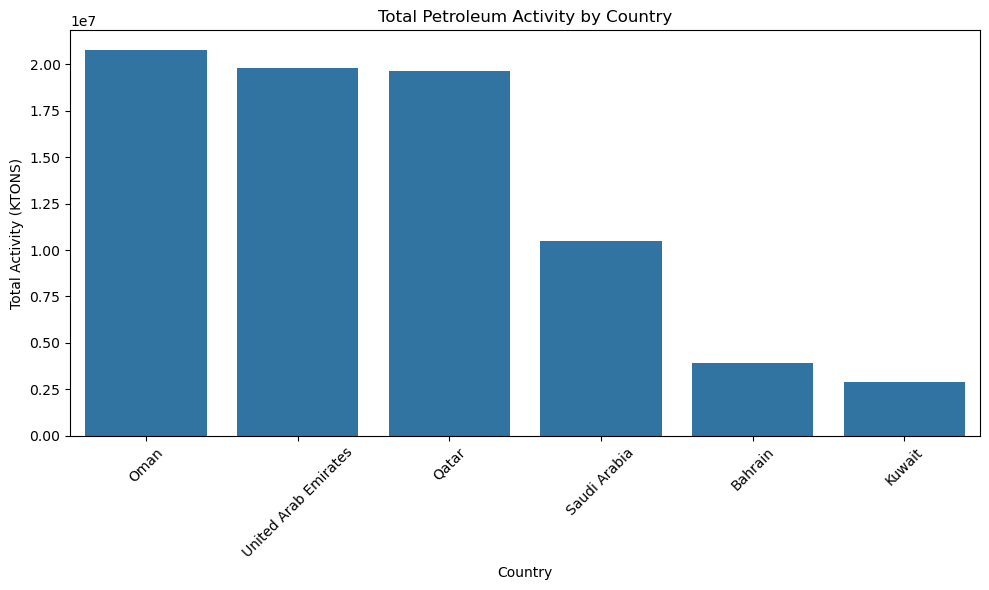

In [31]:
# Sum petroleum activity for each country
country_activity = (
    df_ktons_flows
    .groupby('AREA')['OBS_VALUE']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Plot
plt.figure(figsize=(10, 6))

sns.barplot(
    data=country_activity,
    x='AREA',
    y='OBS_VALUE'
)

plt.title('Total Petroleum Activity by Country')
plt.xlabel('Country')
plt.ylabel('Total Activity (KTONS)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## II: Production Trend Over Time

• ***Visualization Type:-*** Line Chart(Seaborn)  
• ***Purpose:-*** Analyze how petroleum production has changed over the years across GCC countries and identify long-term growth or decline trends.  
• ***Insight:-*** From the plot it is clear that in all the GCC countires together from 2021 we they had an increase in the prodcution and then each year the production has decreased.



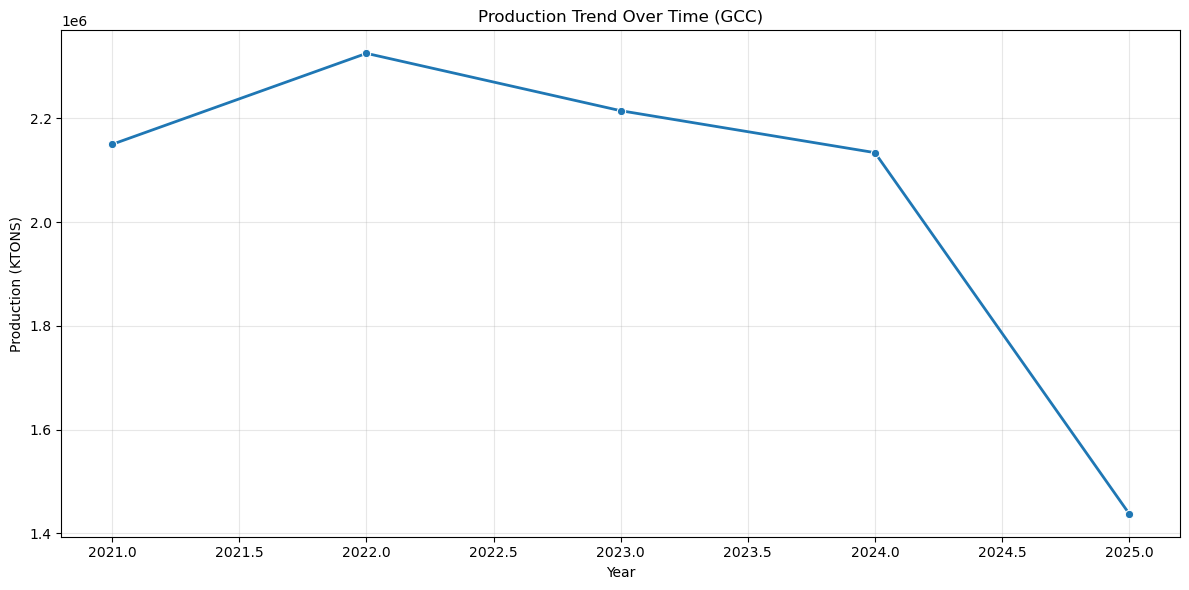

In [32]:
# Filter Production records
production_df = df_ktons_flows[
    df_ktons_flows['FLOW_BREAKDOWN'] == 'Production'
]

# Aggregate yearly production
yearly_production = (
    production_df
    .groupby('Year')['OBS_VALUE']
    .sum()
    .reset_index()
)

# Plot
plt.figure(figsize=(12,6))

sns.lineplot(
    data=yearly_production,
    x='Year',
    y='OBS_VALUE',
    marker='o',
    linewidth=2
)

plt.title('Production Trend Over Time (GCC)')
plt.xlabel('Year')
plt.ylabel('Production (KTONS)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## III. Demand Trend Over Time

• ***Visualization Type:-*** Line Chart(Seaborn)  
• ***Purpose:-*** Analyze how petroleum production has changed over the years across GCC countries and identify long-term growth or decline trends.  
• ***Insight:-*** From the plot it is clear that in all the GCC countires together from 2021 had a stable demand trend and by  the last year it had a decline. In 2025 we are only taking 8 months into consideration so that is one reason behind the decline.

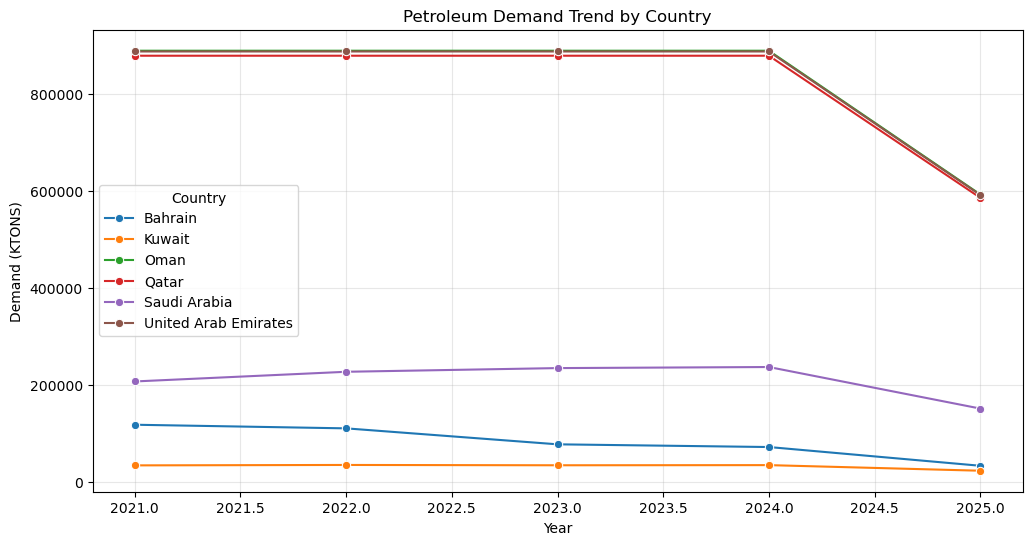

In [34]:
country_demand = (
    demand_df
    .groupby(['Year', 'AREA'])['OBS_VALUE']
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=country_demand,
    x='Year',
    y='OBS_VALUE',
    hue='AREA',
    marker='o'
)

plt.title('Petroleum Demand Trend by Country')
plt.xlabel('Year')
plt.ylabel('Demand (KTONS)')
plt.legend(title='Country')
plt.grid(alpha=0.3)

plt.show()

## IV. Imports vs Exports by Country

• ***Visualization Type:-*** Grouped Bar CHart(Seaborn)  
• ***Purpose:-*** To compare the volume of petroleum imports and exports across GCC countries. This visualization helps identify countries that are net exporters, net importers, or have a balanced trade position in petroleum products.  
• ***Insight:-*** The Imports vs Exports analysis reveals substantial differences in petroleum trade patterns among GCC countries. While some countries act as major exporters due to their large production capacity, others exhibit higher import volumes to satisfy domestic demand. Understanding these trade dynamics helps assess energy security, market dependence, and each country's position within the GCC petroleum supply chain.

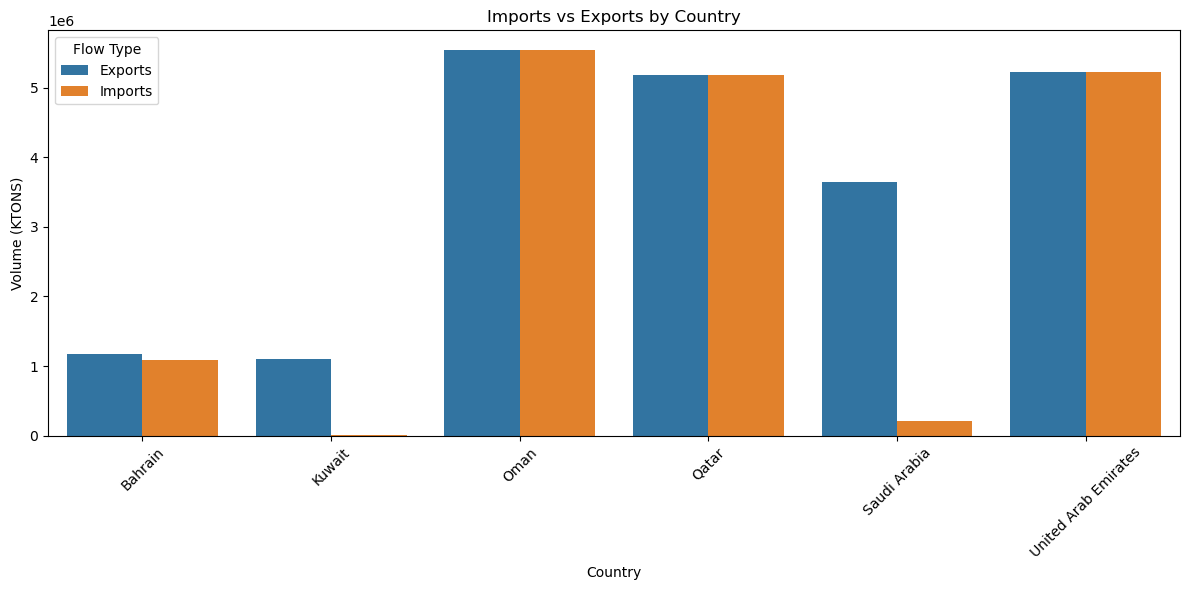

In [29]:

trade_df = df_ktons_flows[
    df_ktons_flows['FLOW_BREAKDOWN'].isin(['Imports', 'Exports'])
]


country_trade = (
    trade_df
    .groupby(['AREA', 'FLOW_BREAKDOWN'])['OBS_VALUE']
    .sum()
    .reset_index()
)


plt.figure(figsize=(12,6))

sns.barplot(
    data=country_trade,
    x='AREA',
    y='OBS_VALUE',
    hue='FLOW_BREAKDOWN'
)

plt.title('Imports vs Exports by Country')
plt.xlabel('Country')
plt.ylabel('Volume (KTONS)')
plt.legend(title='Flow Type')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## V. Production vs Demand by Country

• ***Visualization Type:-*** Grouped Bar Chart(Seaborn)  

• ***Purpose:-*** To compare petroleum production and demand across GCC countries. This visualization helps assess whether countries produce enough petroleum products to satisfy domestic consumption and identify potential surplus or deficit situations.
 
• ***Insight:-*** Comparing production and demand provides an indication of energy self-sufficiency within GCC countries. Countries with substantial production surpluses may have stronger export potential, while those with higher demand relative to production may face greater dependence on imports or external supply sources.

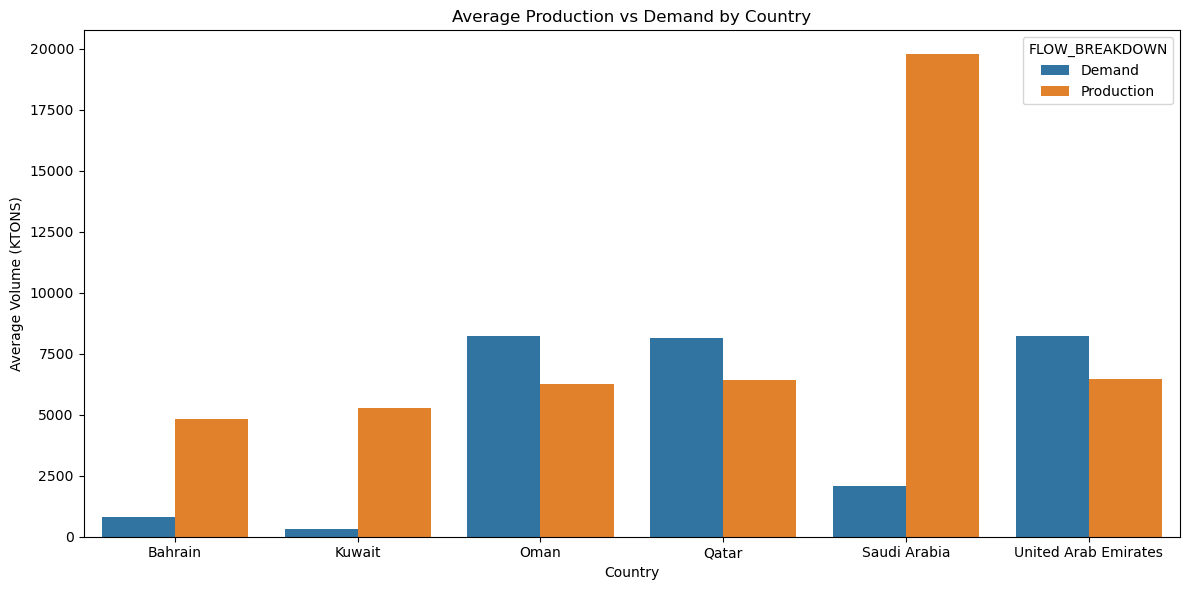

In [31]:
country_prod_demand_avg = (
    prod_demand_df
    .groupby(['AREA', 'FLOW_BREAKDOWN'])['OBS_VALUE']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=country_prod_demand_avg,
    x='AREA',
    y='OBS_VALUE',
    hue='FLOW_BREAKDOWN'
)

plt.title('Average Production vs Demand by Country')
plt.xlabel('Country')
plt.ylabel('Average Volume (KTONS)')

plt.tight_layout()
plt.show()

## VI. Refinery Output Trend By Country

• ***Visualization Type:-*** MultiLine Chart(Seaborn)  

• ***Purpose:-*** To analyze how refinery output has changed over time for each GCC country. This visualization helps identify countries with growing refining capacity, stable refinery operations, or declining refinery activity.

• ***Insight:-*** Refinery output serves as a key indicator of downstream petroleum sector performance. Monitoring refinery output trends helps assess refining capacity utilization, production efficiency, and each country's ability to add value to crude oil through refining operations. Countries with sustained refinery output growth may strengthen their position in regional and international petroleum markets

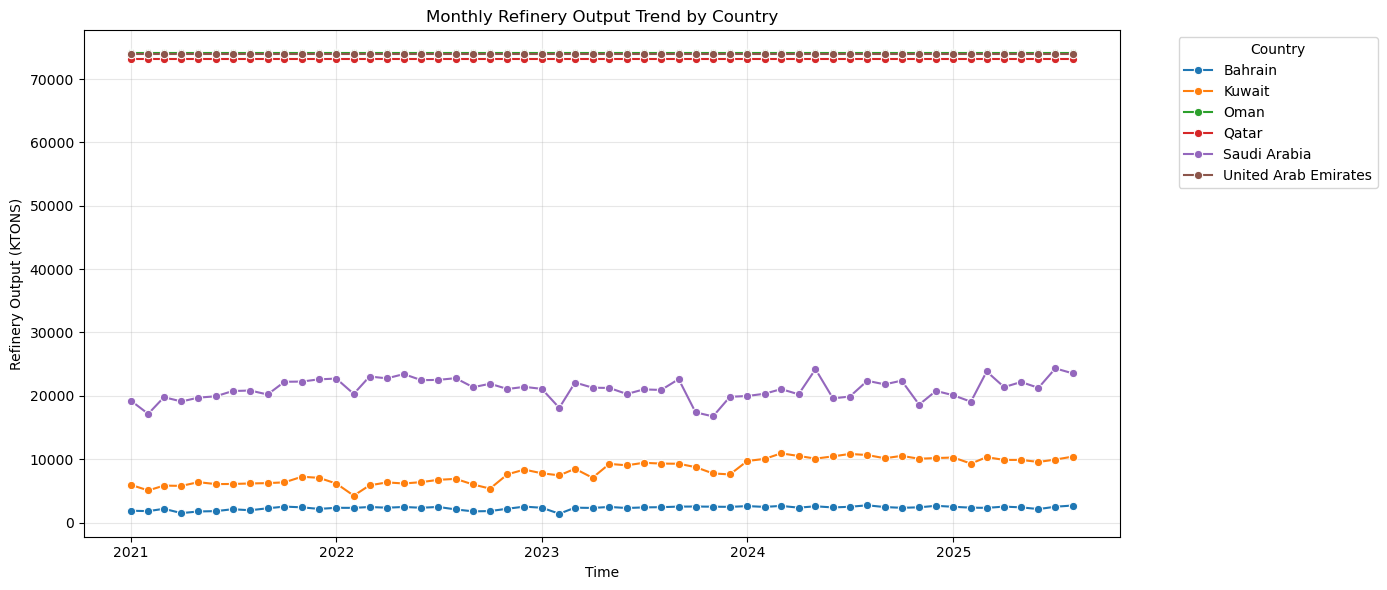

In [33]:
# Filter Refinery Output records
refinery_df = df_ktons_flows[
    df_ktons_flows['FLOW_BREAKDOWN'] == 'Refinery output'
]

# Aggregate monthly refinery output
refinery_monthly = (
    refinery_df
    .groupby(['TIME_PERIOD', 'AREA'])['OBS_VALUE']
    .sum()
    .reset_index()
)

# Plot
plt.figure(figsize=(14,6))

sns.lineplot(
    data=refinery_monthly,
    x='TIME_PERIOD',
    y='OBS_VALUE',
    hue='AREA',
    marker='o'
)

plt.title('Monthly Refinery Output Trend by Country')
plt.xlabel('Time')
plt.ylabel('Refinery Output (KTONS)')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## VII. Monthly Demand Seasonality For Kuwait, Bahrain anf Saudi Arabia

• ***Visualization Type:-*** Heat Map(Seaborn)  

• ***Purpose:-*** To analyze how refinery output has changed over time for each GCC country. This visualization helps identify countries with growing refining capacity, stable refinery operations, or declining refinery activity.

• ***Insight:-*** The heatmap reveals distinct demand patterns across GCC countries. Saudi Arabia maintains the highest petroleum demand throughout the year, while Bahrain experiences stronger seasonal fluctuations. Kuwait's demand remains comparatively stable. The increase in demand during summer months, particularly in Saudi Arabia, suggests seasonal influences on petroleum consumption and highlights the importance of demand forecasting for operational planning and resource allocation.

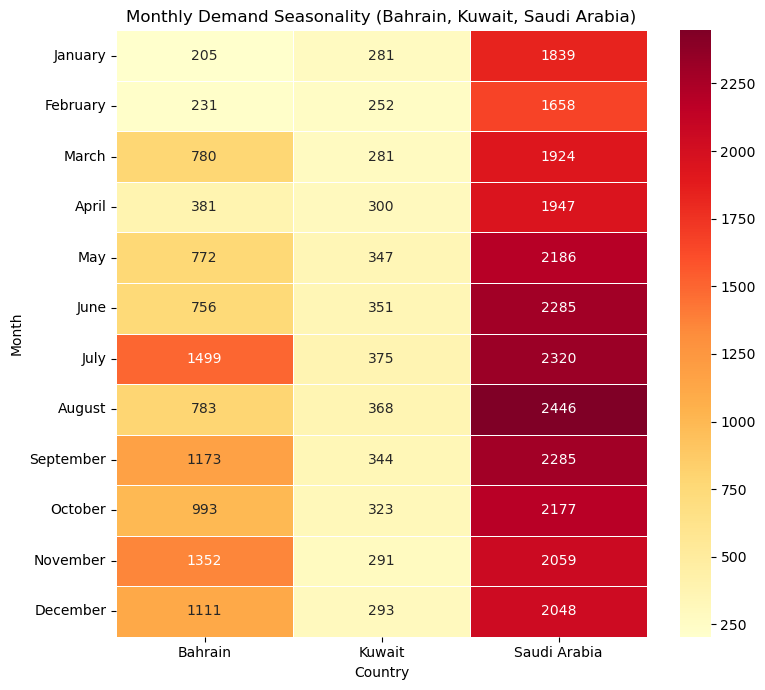

In [35]:
# Filter Demand records
demand_df = df_ktons_flows[
    df_ktons_flows['FLOW_BREAKDOWN'] == 'Demand'
]

# Keep only countries with meaningful monthly variation
countries_to_keep = ['Bahrain', 'Kuwait', 'Saudi Arabia']

demand_filtered = demand_df[
    demand_df['AREA'].isin(countries_to_keep)
]

# Month order
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

# Average monthly demand
seasonality = (
    demand_filtered
    .groupby(['Month_Name', 'AREA'])['OBS_VALUE']
    .mean()
    .reset_index()
)

# Create pivot table
seasonality_pivot = seasonality.pivot(
    index='Month_Name',
    columns='AREA',
    values='OBS_VALUE'
)

# Sort months correctly
seasonality_pivot = seasonality_pivot.reindex(month_order)

# Plot heatmap
plt.figure(figsize=(8, 7))

sns.heatmap(
    seasonality_pivot,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5
)

plt.title('Monthly Demand Seasonality (Bahrain, Kuwait, Saudi Arabia)')
plt.xlabel('Country')
plt.ylabel('Month')

plt.tight_layout()
plt.show()

## VIII. Correlation between Petroleum FLows

• ***Visualization Type:-*** Correlation Heat Map(Seaborn)  

• ***Purpose:-*** The purpose of this visualization is to examine the relationships between key petroleum flows in the GCC region. Correlation analysis helps determine whether changes in one petroleum activity are associated with changes in another.

• ***Insight:-*** The correlation analysis reveals a very strong positive relationship between petroleum production and exports (0.96), indicating that increased production is closely associated with higher export volumes. A moderate positive correlation exists between imports and refinery output (0.54), suggesting that imports may support refining activities. Demand exhibits weak correlations with production, imports, and refinery output, implying that domestic consumption is not the primary driver of petroleum production and refining decisions within GCC countries. Overall, the results highlight the export-oriented nature of the GCC petroleum sector and the strong connection between production and international trade.

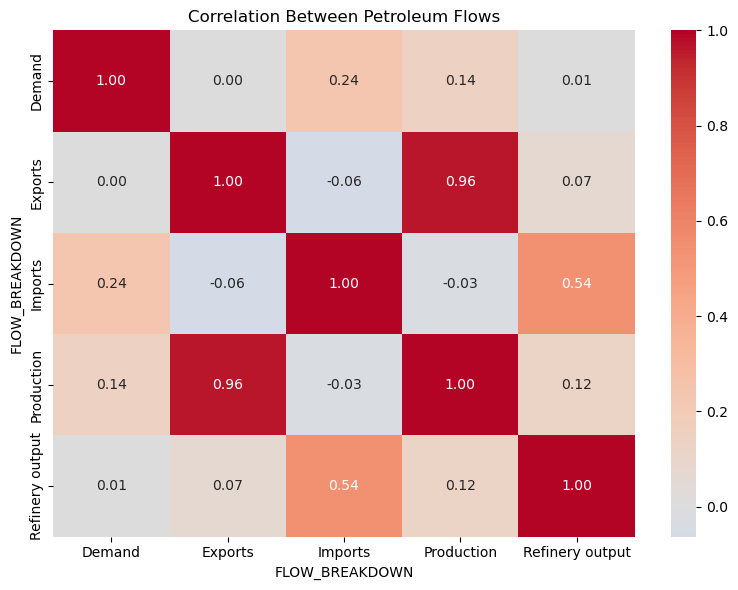

In [36]:
# Select important petroleum flows
selected_flows = [
    'Production',
    'Imports',
    'Exports',
    'Refinery output',
    'Demand'
]

corr_df = df_ktons_flows[
    df_ktons_flows['FLOW_BREAKDOWN'].isin(selected_flows)
]

# Aggregate by time and flow
pivot_df = (
    corr_df
    .pivot_table(
        index='TIME_PERIOD',
        columns='FLOW_BREAKDOWN',
        values='OBS_VALUE',
        aggfunc='sum'
    )
)

# Correlation matrix
corr_matrix = pivot_df.corr()

# Plot
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title('Correlation Between Petroleum Flows')

plt.tight_layout()
plt.show()

## ix. Growth Percentage by Country and Flow Type

• ***Visualization Type:-*** HeatMap(Seaborn)  

• ***Purpose:-*** The purpose of this visualization is to compare the average growth rates of different petroleum activities (Production, Imports, Exports, Refinery Output, and Demand) across GCC countries.

• ***Insight:-*** The growth analysis reveals distinct petroleum sector trends across GCC countries. Kuwait recorded the strongest growth in imports (108%), indicating increasing reliance on imported petroleum products or refinery inputs. Saudi Arabia demonstrated the highest refinery output growth (23.2%), reflecting expansion in downstream operations. Production growth remained relatively stable across all countries, while Bahrain exhibited exceptionally high demand growth, likely influenced by low baseline values rather than sustained demand expansion.

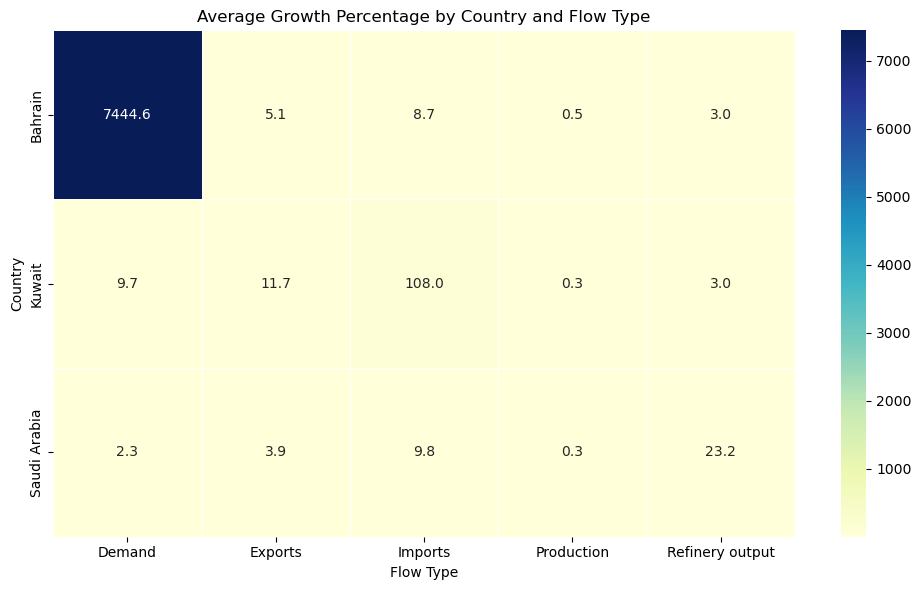

In [44]:
selected_flows = [
    'Production',
    'Imports',
    'Exports',
    'Refinery output',
    'Demand'
]

growth_df = growth_df[
    growth_df['FLOW_BREAKDOWN'].isin(selected_flows)
]

# Remove countries with missing/constant data
countries_to_keep = [
    'Bahrain',
    'Kuwait',
    'Saudi Arabia'
]

growth_df = growth_df[
    growth_df['AREA'].isin(countries_to_keep)
]

# Calculate average growth percentage
growth_summary = (
    growth_df
    .groupby(['AREA', 'FLOW_BREAKDOWN'])['GROWTH_PERCENTAGE']
    .mean()
    .reset_index()
)

# Create heatmap table
growth_pivot = growth_summary.pivot(
    index='AREA',
    columns='FLOW_BREAKDOWN',
    values='GROWTH_PERCENTAGE'
)

# Plot Heatmap
plt.figure(figsize=(10, 6))

sns.heatmap(
    growth_pivot,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    linewidths=0.5
)

plt.title('Average Growth Percentage by Country and Flow Type')
plt.xlabel('Flow Type')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

## x. Kuwait vs Other GCC Countries

• ***Visualization Type :-*** Grouped Bar Chart

• ***Purpose :-*** The purpose of this visualization is to compare Kuwait's petroleum activities against other GCC countries across key petroleum flows such as:

• ***Insight :-*** The Kuwait vs Other GCC Countries analysis highlights the relative scale and structure of petroleum activities across the region. Kuwait maintains a strong presence in production, exports, and refining activities, although Saudi Arabia generally leads in overall petroleum volumes. These findings provide valuable insights into regional market dynamics and Kuwait's strategic role within the GCC petroleum sector.

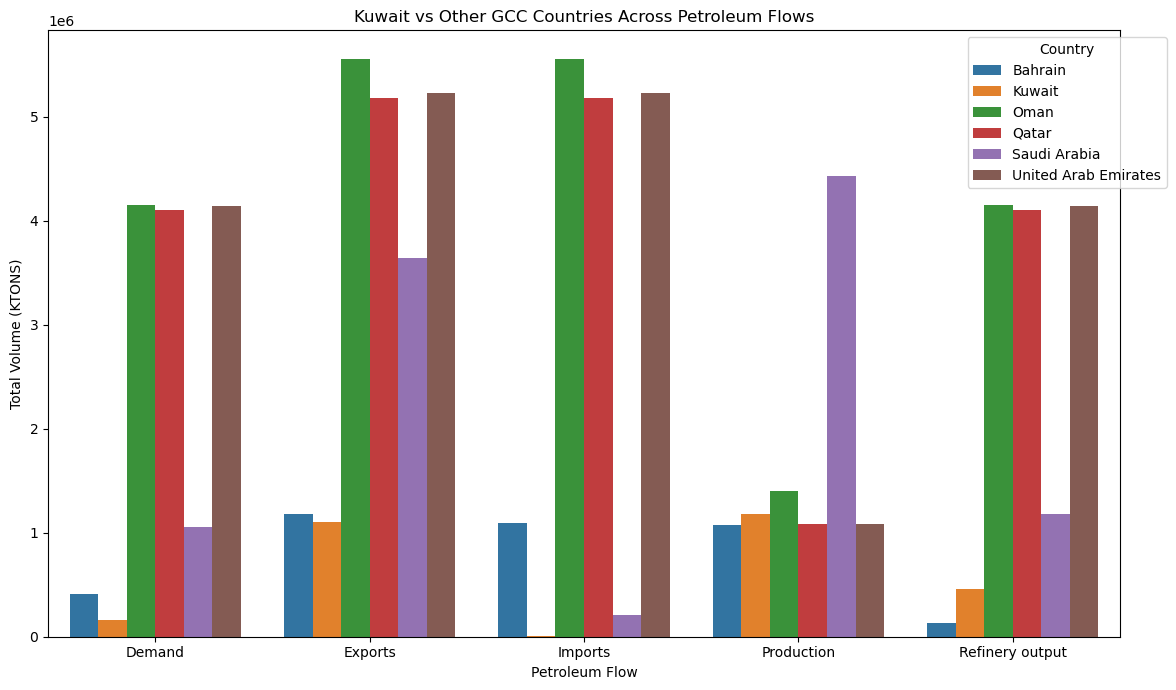

In [43]:
# Select major petroleum flows
selected_flows = [
    'Production',
    'Imports',
    'Exports',
    'Refinery output',
    'Demand'
]

kuwait_comparison = (
    df_ktons_flows[
        df_ktons_flows['FLOW_BREAKDOWN'].isin(selected_flows)
    ]
    .groupby(['AREA', 'FLOW_BREAKDOWN'])['OBS_VALUE']
    .sum()
    .reset_index()
)

plt.figure(figsize=(14,7))

sns.barplot(
    data=kuwait_comparison,
    x='FLOW_BREAKDOWN',
    y='OBS_VALUE',
    hue='AREA'
)

plt.title('Kuwait vs Other GCC Countries Across Petroleum Flows')
plt.xlabel('Petroleum Flow')
plt.ylabel('Total Volume (KTONS)')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

## xi. Top Energy Products by Production

• ***Visualization Type :-*** Horizontal Bar Chart

• ***Purpose :-*** The purpose of this visualization is to identify the petroleum products with the highest production volumes across GCC countries.

• ***Insight :-*** The Top Energy Products by Production analysis reveals the most significant petroleum products within the GCC energy sector. Production is concentrated among a limited number of high-volume products, highlighting their importance in supporting regional energy supply, refining activities, and export markets. These findings provide insight into the structure of petroleum production and the products that drive industry performance.

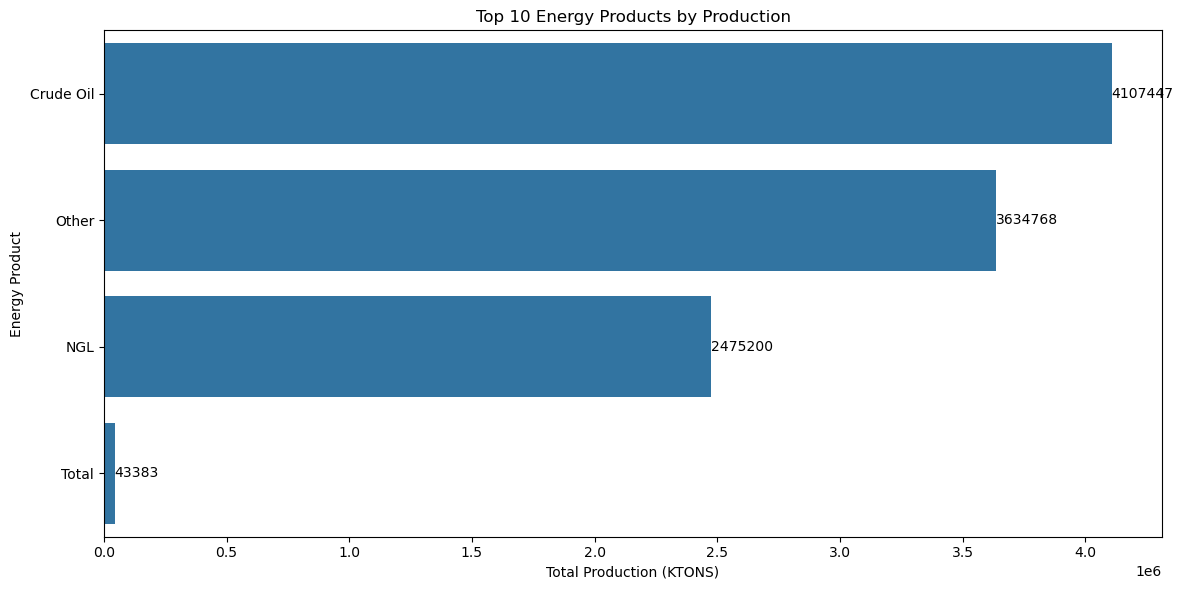

In [46]:
# Filter Production data
production_df = df_ktons_flows[
    df_ktons_flows['FLOW_BREAKDOWN'] == 'Production'
]

# Aggregate production
top_products = (
    production_df
    .groupby('ENERGY_PRODUCT_NAME')['OBS_VALUE']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top_products,
    x='OBS_VALUE',
    y='ENERGY_PRODUCT_NAME'
)

# Add labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.title('Top 10 Energy Products by Production')
plt.xlabel('Total Production (KTONS)')
plt.ylabel('Energy Product')

plt.tight_layout()
plt.show()

<h2 style="
    text-align:center;
    background-color:#eef3ff;
    padding:10px 15px;
    border-radius:5px;
    color:#2c7be5;
    font-size:30px
">
 Insight Generation and Report
</h2>

<h2 style ="font-size:24px">Objective of the Analysis</h2>

<p style="font-size:16px;text-align:justify">The primary objective of this analysis is to examine and understand energy production, trade, and demand patterns across GCC countries using historical dataset trends.</p>

<h2 style ="font-size:24px">Data Preparation Summary</h2>

<p style="font-size:16px;text-align:justify">The original dataset consisted of 1107600 records with mixed numerical and categorical features. Several preprocessing steps were undertaken to enhance data quality and analytical reliability, including handling missing values, removing invalid and rare records, filtering out by selecting just one unit measure, and eliminating non-informative identifiers.<br>
Feature engineering steps such as year , month, quarter, growth percentage, production mappping was carried out. After preprocessing, the final dataset comprised 42560 records forming a robust foundation for analysis.

<h2 style ="font-size:24px">Exploratory Data Analysis Overview</h2>

<p style="font-size:16px;text-align:justify">The exploratory data analysis was conducted on a structured energy dataset covering GCC countries, focusing on key energy metrics such as production, imports, exports, refinery output, and demand. The dataset includes temporal dimensions (monthly and yearly) along with categorical attributes such as country/area, energy product type, flow breakdown, and unit measures.</p>

<h2 style ="font-size:24px">Key Analytical Insights from Visual Exploration</h2>

<h2 style ="font-size:20px">(i) Production Dominates Overall Energy Activity</h2>

<p style="font-size:16px;text-align:justify">Visual comparison of flow breakdowns shows that production and refinery output consistently account for the largest share of total energy activity across GCC countries. Other flows such as imports and exports remain significantly lower in magnitude, indicating a production-heavy energy structure.</p>

<h2 style ="font-size:20px">(ii) Kuwait Shows More Stable Trends Compared to Other GCC Countries</h2>

<p style="font-size:16px;text-align:justify">Time-series visualizations indicate that Kuwait has relatively stable production and refinery output patterns, with fewer sharp fluctuations. In contrast, other GCC countries show higher volatility, especially in exports and demand-related flows.</p>

<h2 style ="font-size:20px">(iii) Clear Seasonal Patterns in Energy Demand and Imports</h2>

<p style="font-size:16px;text-align:justify">Line charts across monthly time periods reveal recurring seasonal fluctuations, particularly in:

>Imports (peaking in specific months), Demand (showing periodic increases and decreases)

This suggests that energy consumption and supply needs are influenced by seasonal or operational cycles.</p>

<h2 style ="font-size:20px">(iv) Export Activity is More Volatile Than Production</h2>

<p style="font-size:16px;text-align:justify">Visual trend analysis shows that exports fluctuate significantly compared to production, indicating that export levels are more sensitive to external market conditions and trade dynamics.</p>

<h2 style ="font-size:20px">(v) Strong Inter-Country Variation in Energy Metrics</h2>

<p style="font-size:16px;text-align:justify">Bar charts and comparative visuals highlight that:

Some GCC countries consistently lead in production and refinery output, Others show stronger activity in imports or exports depending on their energy structure

This confirms non-uniform energy dependency and specialization across the region.</p>

<h2 style ="font-size:20px">(vi) Growth Trends Indicate Mixed Performance Across Flows</h2>

<p style="font-size:16px;text-align:justify">Growth percentage visualizations show:

Positive and stable growth in production for selected countries (especially Kuwait), Fluctuating or inconsistent growth in imports and exports, Occasional spikes indicating short-term market or operational changes</p>

<h2 style ="font-size:24px">Overall Findings and Conclusion</h2>

<p style="font-size:16px;text-align:justify">Overall, the GCC energy landscape is characterized by stable production foundations, regionally varying performance, and highly dynamic trade and demand behavior. Kuwait demonstrates relative stability, while other GCC countries exhibit more fluctuating patterns across key energy indicators. These insights can support better energy planning, forecasting, and policy decision-making by identifying stability drivers, seasonal effects, and volatility risks within the regional energy system.</p>

<div style="
    border-left: 6px solid #27ae60;
    background-color: #f3fcf7;
    padding: 16px 18px;
    margin-top: 20px;
    font-size: 15px;
    color: #2c3e50;
    border-radius: 4px;
">
<strong>✔ Project Completed Successfully</strong><br><br>
This project successfully completed data preprocessing, exploratory data analysis, analytical visualizations, insight generation, and reporting. The findings provide clear, data-driven understanding of stroke risk factors and support informed analytical and decision-making outcomes.
</div>